## Exercise 1: K-Nearest Neighbors on Moons Dataset

Apply the k-nearest neighbors algorithm on the moons dataset. The number of samples of this dataset is 200. Split the data such that the test split is 45% of the initial dataset. Set the number of neighbors parameter to 2 and compute the accuracy on the test set. Visualize the decision boundary of the KNN classifiers using different values for k = {1,5,9}.

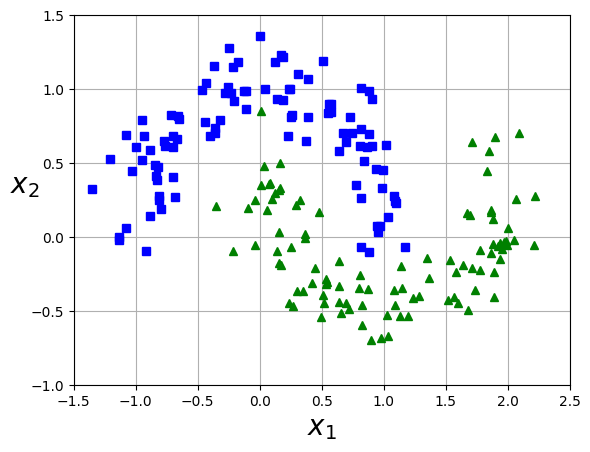

In [9]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.45, random_state=0
)


def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], "bs")
    plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], "g^")
    plt.axis(axes)
    plt.grid(True, which="both")
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)


plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=2)
print(clf.fit(X_train, y_train))
print(clf.predict(X_test))
print(clf.score(X_test, y_test))

KNeighborsClassifier(n_neighbors=2)
[0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 0 1 0 1 0 0
 1 1 0 0 0 0 1 1 0 1 1 1 0 1 0 1 0 0 0 0 1 0 1 0 1 0 0 0 1 1 1 1 1 1 0 0 0
 0 0 1 1 0 1 1 0 0 1 1 0 0 0 0 0]
0.9888888888888889


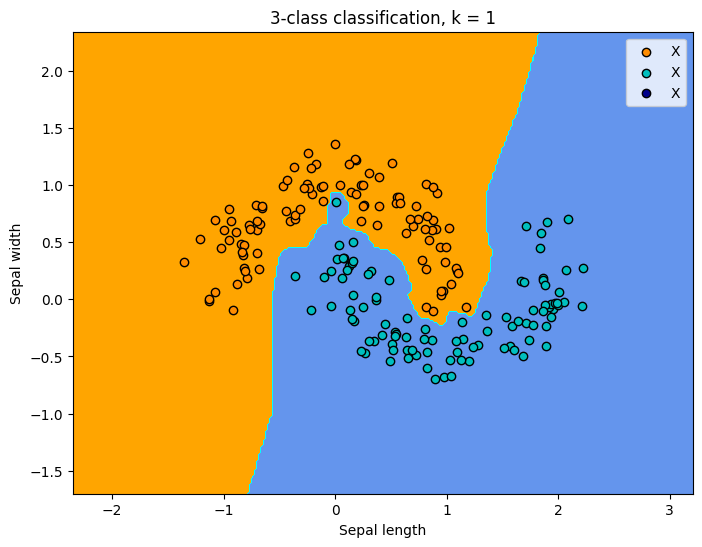

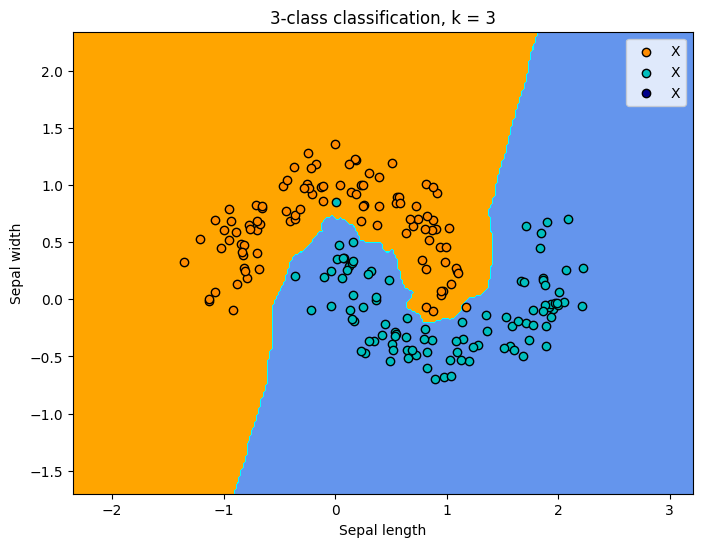

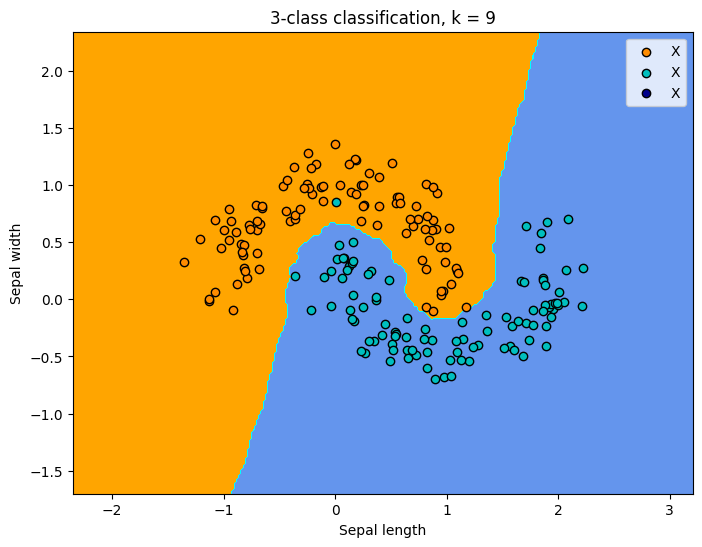

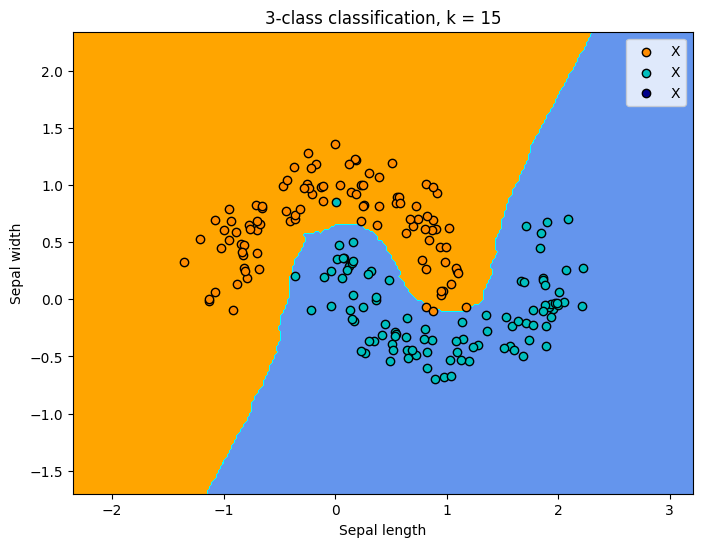

In [11]:
import numpy as np
from matplotlib.colors import ListedColormap

h = 0.02  # Step size in the mesh

# Create color maps
cmap_light = ListedColormap(["orange", "cyan", "cornflowerblue"])
cmap_bold = ["darkorange", "c", "darkblue"]

for n_neighbors in [1, 3, 9, 15]:
    # We create an instance of KNeighborsClassifier and fit the data.
    clf = KNeighborsClassifier(n_neighbors)
    clf.fit(X, y)

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    for i in range(3):
        plt.scatter(
            X[:, 0][y == i],
            X[:, 1][y == i],
            c=cmap_bold[i],
            edgecolors="black",
            label="X",
        )

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("3-class classification, k = %i" % (n_neighbors))
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.legend()

plt.show()

## Exercise 2: Nonlinear SVM Classification

Use the following dataset:
```python
X1, y1 = make_gaussian_quantiles(cov=7., n_samples=250, n_features=2, n_classes=3, random_state=1)
```

Apply the nonlinear SVM classification. Use the polynomial kernel with degree = 3, coef0 = 10, C = 5, respectively. Plot the decision boundary of the nonlinear SVM classification.

In [12]:
from sklearn.datasets import make_gaussian_quantiles
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X1, y1 = make_gaussian_quantiles(
    cov=7.0, n_samples=250, n_features=2, n_classes=3, random_state=1
)

poly_kernel_svm_clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="poly", degree=3, coef0=10, C=5)),
    ]
)
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=10, kernel='poly'))])

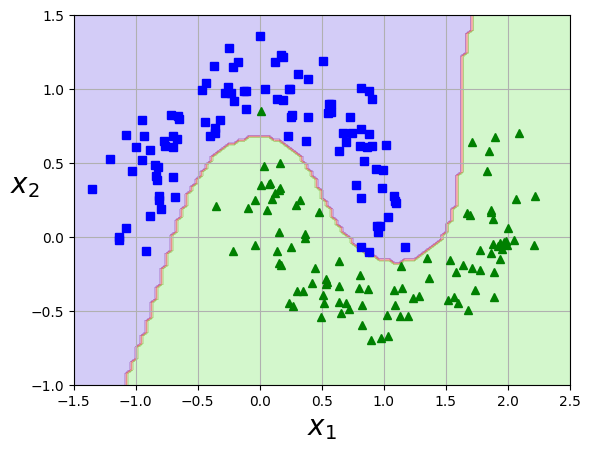

In [13]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)


plot_predictions(poly_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

plt.show()

## Exercise 3: Linear SVM Regression

Apply linear SVM regression to the following dataset:
```python
X = 6 - np.random.rand(n, 1)
y = (1 - 2 * X + np.random.randn(n, 1)).ravel()
```

Set the width of the margin to 0.8 and plot the fit line.

In [14]:
np.random.seed(42)
n = 50
X = 6 - np.random.rand(n, 1)
y = (1 - 2 * X + np.random.randn(n, 1)).ravel()

In [15]:
from sklearn.svm import LinearSVR

svm_reg1 = LinearSVR(epsilon=0.8, random_state=42)
svm_reg2 = LinearSVR(epsilon=0.5, random_state=42)
svm_reg1.fit(X, y)
svm_reg2.fit(X, y)


def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    off_margin = np.abs(y - y_pred) >= svm_reg.epsilon
    return np.argwhere(off_margin)


svm_reg1.support_ = find_support_vectors(svm_reg1, X, y)
svm_reg2.support_ = find_support_vectors(svm_reg2, X, y)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


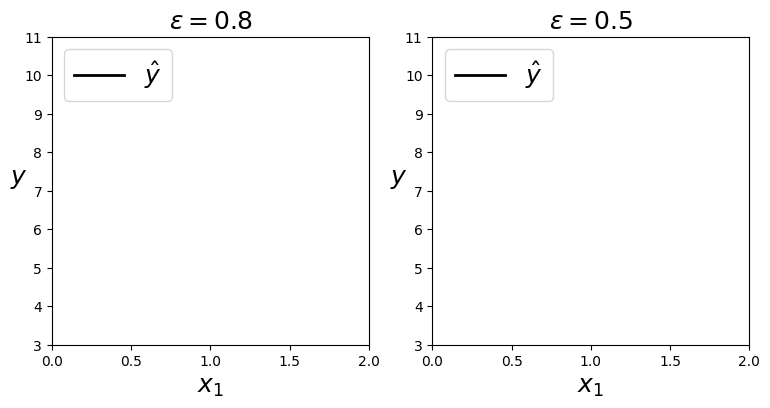

In [16]:
def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = svm_reg.predict(x1s)
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$")
    plt.plot(x1s, y_pred + svm_reg.epsilon, "k--")
    plt.plot(x1s, y_pred - svm_reg.epsilon, "k--")
    plt.scatter(X[svm_reg.support_], y[svm_reg.support_], s=200, facecolors="#FFAAAA")
    plt.plot(X, y, "bo")
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.legend(loc="upper left", fontsize=18)
    plt.axis(axes)


fig, axes = plt.subplots(ncols=2, figsize=(9, 4))
plt.sca(axes[0])
plot_svm_regression(svm_reg1, X, y, [0, 2, 3, 11])
plt.title(r"$\epsilon = {}$".format(svm_reg1.epsilon), fontsize=18)
plt.ylabel(r"$y$", fontsize=18, rotation=0)

plt.sca(axes[1])
plot_svm_regression(svm_reg2, X, y, [0, 2, 3, 11])
plt.title(r"$\epsilon = {}$".format(svm_reg2.epsilon), fontsize=18)
plt.ylabel(r"$y$", fontsize=18, rotation=0)
plt.show()